In [80]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import warnings
import nltk

warnings.filterwarnings('ignore')

In [81]:
# One-time NLTK resource downloads (punkt_tab is required by newer NLTK versions)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Shree\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Shree\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shree\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [82]:
data = pd.read_csv('data/spam.csv', encoding='latin-1')
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [83]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [84]:
# Rename columns
data.rename(columns={'v1': 'label', 'v2': 'text'}, inplace=True)

# Drop the mostly-empty (>99% missing) unnamed columns
print(data.isna().sum())
data.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)
data.info()

label            0
text             0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   5572 non-null   str  
 1   text    5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [85]:
data.isna().sum()

label    0
text     0
dtype: int64

In [87]:
# Encode labels: ham -> 0, spam -> 1
data['label'] = data['label'].map({'ham': 0, 'spam': 1})
data.head()

,label,text
0,NaN,"Go until jurong point, crazy.. Available only ..."
1,NaN,Ok lar... Joking wif u oni...
2,NaN,Free entry in 2 a wkly comp to win FA Cup fina...
3,NaN,U dun say so early hor... U c already then say...
4,NaN,"Nah I don't think he goes to usf, he lives aro..."


In [90]:
# Remove duplicate rows (this step was missing from the original notebook)
print('Duplicates before:', data.duplicated().sum())
data = data.drop_duplicates(keep='first').reset_index(drop=True)
print('Duplicates after:', data.duplicated().sum())
print('Shape:', data.shape)

Duplicates before: 403
Duplicates after: 0
Shape: (5169, 2)


In [89]:
data.shape

(5572, 2)

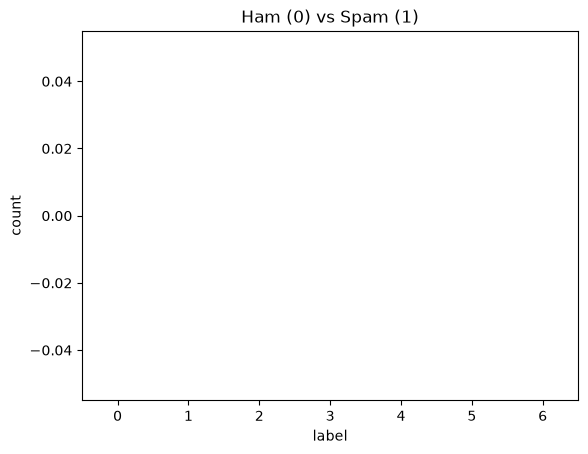

In [91]:
data_eda = data.copy()
sns.countplot(x='label', data=data_eda)
plt.title('Ham (0) vs Spam (1)')
plt.show()


In [92]:
data_eda['num_characters'] = data_eda['text'].apply(len)
data_eda['words_count'] = data_eda['text'].apply(lambda x: len(nltk.word_tokenize(x)))
data_eda['num_sentences'] = data_eda['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
data_eda.describe()

,label,num_characters,words_count,num_sentences
count,0.0,5169.000000,5169.000000,5169.000000
mean,NaN,78.977945,18.460437,1.965564
std,NaN,58.236293,13.334441,1.448541
min,NaN,2.000000,1.000000,1.000000
25%,NaN,36.000000,9.000000,1.000000
50%,NaN,60.000000,15.000000,1.000000
75%,NaN,117.000000,26.000000,2.000000
max,NaN,910.000000,220.000000,38.000000


In [93]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))  # load once, not per word


def nlp_transform(text):
    """Lowercase -> tokenize -> keep alphanumeric, non-stopwords -> stem."""
    tokens = nltk.word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalnum() and t not in stop_words]
    return " ".join(ps.stem(t) for t in tokens)


nlp_transform("Free entry in 2 a wkly comp to win FA Cup final tkts!")


'free entri 2 wkli comp win fa cup final tkt'

In [94]:
data_eda['nlp_transformed_text'] = data_eda['text'].apply(nlp_transform)
data_eda.head()

,label,text,num_characters,words_count,num_sentences,nlp_transformed_text
0,NaN,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,NaN,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,NaN,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,NaN,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,NaN,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


ValueError: We need at least 1 word to plot a word cloud, got 0.

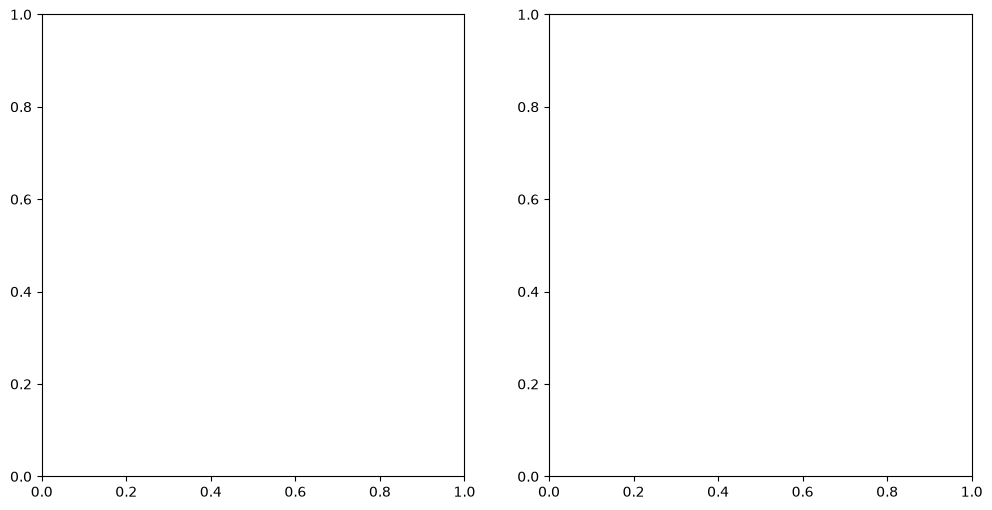

In [ ]:
from wordcloud import WordCloud

wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

spam_text = " ".join(
    data_eda.loc[data_eda['label'] == 1, 'nlp_transformed_text']
    .dropna()
    .astype(str)
)
ham_text = " ".join(
    data_eda.loc[data_eda['label'] == 0, 'nlp_transformed_text']
    .dropna()
    .astype(str)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

if spam_text.strip():
    axes[0].imshow(wc.generate(spam_text))
    axes[0].set_title('Spam')
else:
    axes[0].text(0.5, 0.5, 'No spam text available', ha='center', va='center')
    axes[0].set_title('Spam')

if ham_text.strip():
    axes[1].imshow(wc.generate(ham_text))
    axes[1].set_title('Ham')
else:
    axes[1].text(0.5, 0.5, 'No ham text available', ha='center', va='center')
    axes[1].set_title('Ham')

for ax in axes:
    ax.axis('off')

plt.show()

In [112]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf = TfidfVectorizer(max_features=3000)
X = tf.fit_transform(data_eda['nlp_transformed_text']).toarray()
X = pd.DataFrame(X, columns=tf.get_feature_names_out())
y = data_eda['label']

print(X.shape, y.shape)

(5169, 3000) (5169,)
